In [21]:
import os

import pandas as pd
from pathlib import Path

os.chdir(r"d:\github\All-in-crawler")
print(os.getcwd())

from src.utils.parsing import parse_args, load_config

import sys
sys.argv = [sys.argv[0]]

args = parse_args()
cfg = load_config(args)

paths = cfg["paths"]

clusters_path = f'{cfg["paths"]["processed"]}'

print(clusters_path)

news_file = Path(clusters_path) / "clusters_defined_distinguished_trends_assessed.csv"

print(news_file)

d:\github\All-in-crawler
data/processed
data\processed\clusters_defined_distinguished_trends_assessed.csv


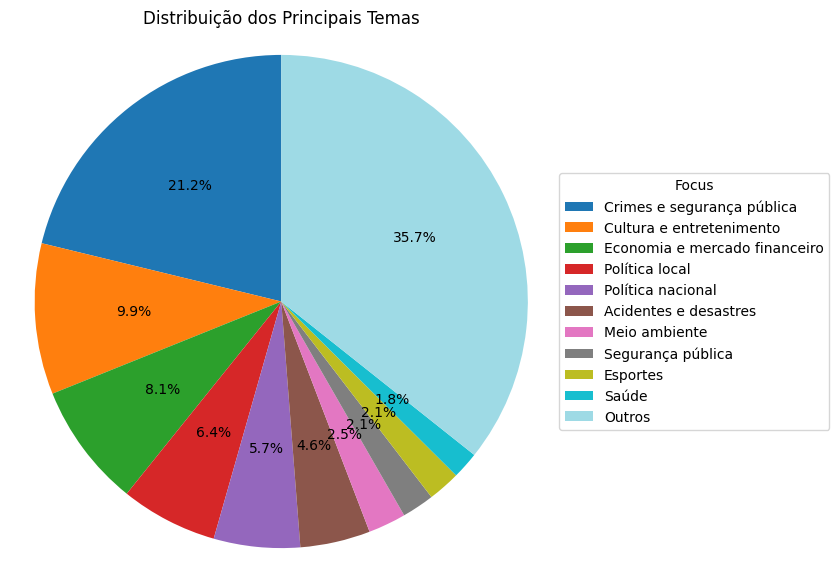

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# carregar dataset
df = pd.read_csv(news_file)

# quebrar múltiplos temas
focus_series = (
    df["Focus"]
    .dropna()
    .str.split("|")
    .explode()
    .str.strip()
)

# contar frequência
focus_counts = focus_series.value_counts()

# pegar top 5
top5 = focus_counts.head(10)

# somar restante
others = focus_counts.iloc[10:].sum()

# combinar
plot_data = pd.concat([top5, pd.Series({"Outros": others})])

# plot
plt.figure(figsize=(7,7))

n = len(plot_data)

colors = plt.cm.tab20(np.linspace(0, 1, n))

wedges, texts, autotexts = plt.pie(
    plot_data.values,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)

plt.legend(
    wedges,
    plot_data.index,
    title="Focus",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.axis('equal')
plt.title("Distribuição dos Principais Temas")

plt.show()

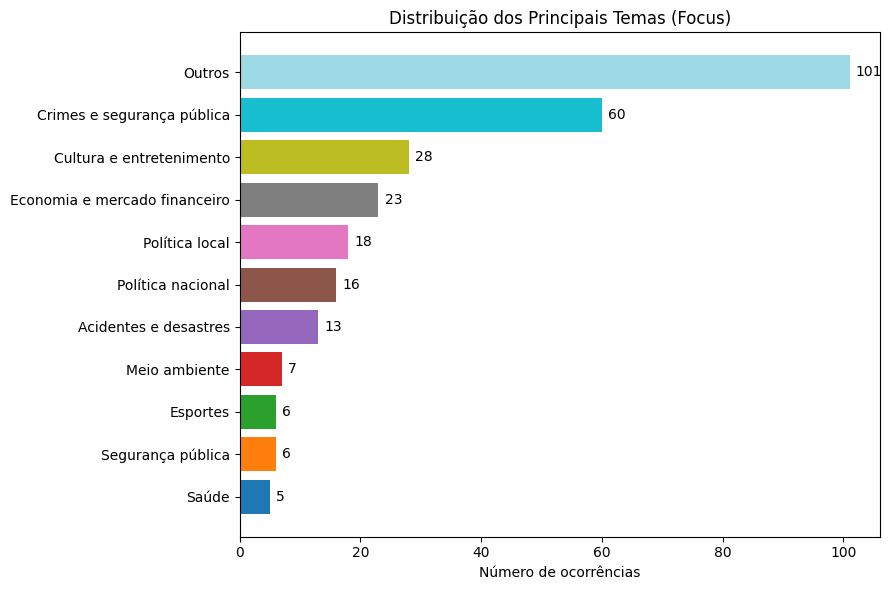

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# carregar dataset
df = pd.read_csv(news_file)

# quebrar múltiplos temas
focus_series = (
    df["Focus"]
    .dropna()
    .str.split("|")
    .explode()
    .str.strip()
)

# contar frequência
focus_counts = focus_series.value_counts()

# pegar top 10
top10 = focus_counts.head(10)

# somar restante
others = focus_counts.iloc[10:].sum()

# combinar
plot_data = pd.concat([top10, pd.Series({"Outros": others})])

# ordenar para gráfico ficar bonito
plot_data = plot_data.sort_values()

# plot barras horizontais
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_data)))

plt.figure(figsize=(9,6))

bars = plt.barh(
    plot_data.index,
    plot_data.values,
    color=colors
)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center')

plt.xlabel("Número de ocorrências")
plt.title("Distribuição dos Principais Temas (Focus)")
plt.tight_layout()

plt.show()

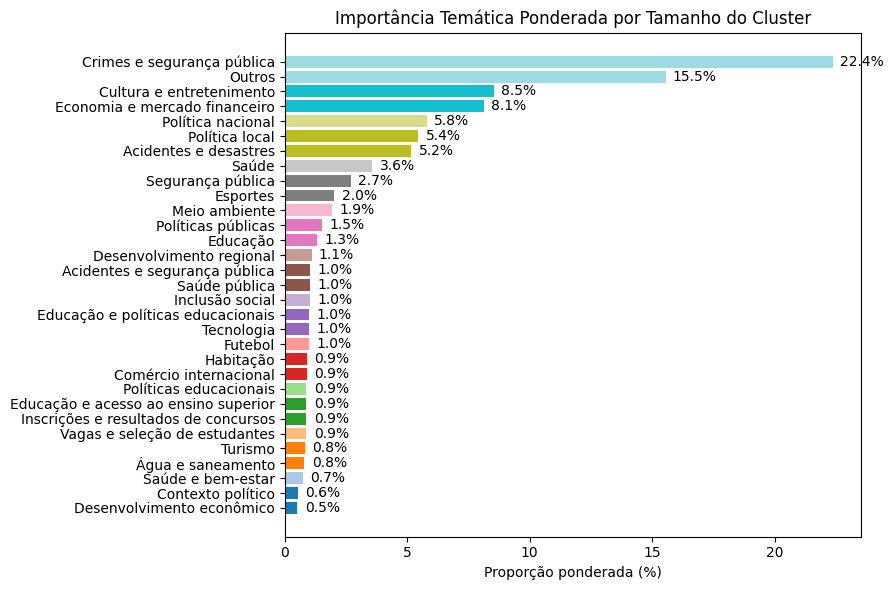

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(news_file)

# separar múltiplos temas
focus_expanded = (
    df[["Focus", "Size"]]
    .dropna()
    .assign(Focus=lambda x: x["Focus"].str.split("|"))
    .explode("Focus")
)

# limpar espaços
focus_expanded["Focus"] = focus_expanded["Focus"].str.strip()

# somar Size por tema
focus_weighted = (
    focus_expanded
    .groupby("Focus")["Size"]
    .sum()
    .sort_values(ascending=False)
)

# pegar top 10
top10 = focus_weighted.head(30)

# agrupar restante
others = focus_weighted.iloc[30:].sum()

plot_data = pd.concat([top10, pd.Series({"Outros": others})])

# converter para proporção
plot_data_pct = plot_data / plot_data.sum() * 100

# ordenar para visualização
plot_data_pct = plot_data_pct.sort_values()

# cores
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_data_pct)))

# gráfico
plt.figure(figsize=(9,6))

bars = plt.barh(plot_data_pct.index, plot_data_pct.values, color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%',
             va='center')

plt.xlabel("Proporção ponderada (%)")
plt.title("Importância Temática Ponderada por Tamanho do Cluster")

plt.tight_layout()
plt.show()

datetime64[ns, UTC]


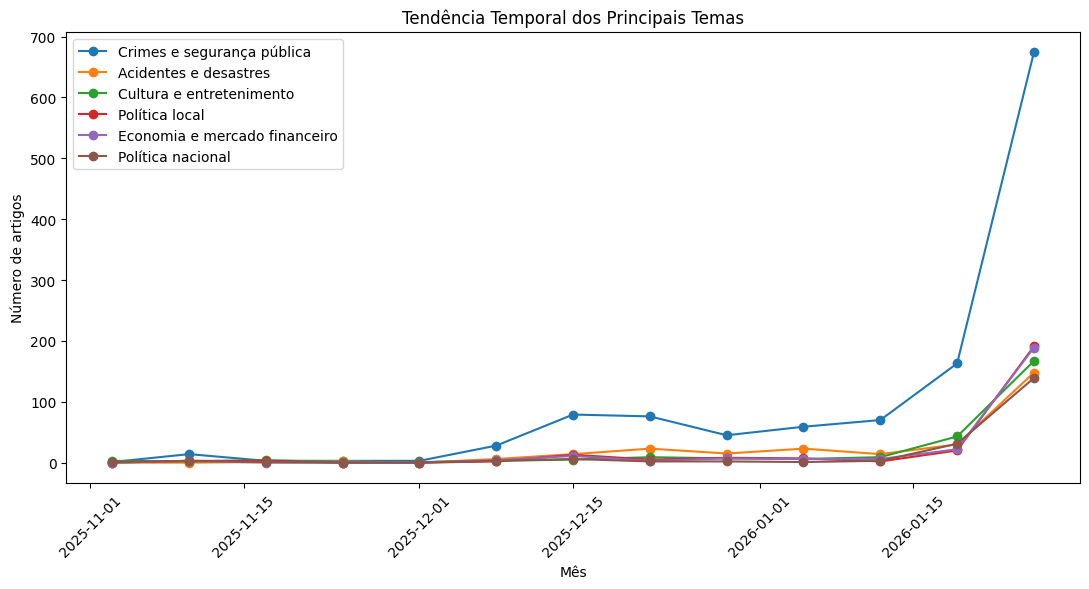

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# carregar datasets
articles_file = Path(clusters_path) / "articles_merged_cleaned_clustered_organized.csv"

news_df = pd.read_csv(articles_file)
clusters_df = pd.read_csv(news_file)

# converter datas
# converter datas (forma robusta)
news_df["publish_date"] = pd.to_datetime(
    news_df["publish_date"],
    errors="coerce",
    utc=True
)

# remover datas inválidas
news_df = news_df.dropna(subset=["publish_date"])

print(news_df["publish_date"].dtype)

# remover timezone
news_df["publish_date"] = news_df["publish_date"].dt.tz_localize(None)

# criar coluna mês
news_df["month"] = news_df["publish_date"].dt.to_period("M")

# juntar artigos com clusters
# filtrar datas
news_df = news_df[news_df["publish_date"] >= "2025-11-01"]

news_df["period"] = news_df["publish_date"]

merged = news_df.merge(
    clusters_df[["Cluster ID", "Focus"]],
    on="Cluster ID",
    how="left"
)

focus_expanded = (
    merged[["period", "Focus"]]
    .dropna()
    .assign(Focus=lambda x: x["Focus"].str.split("|"))
    .explode("Focus")
)

focus_expanded["Focus"] = focus_expanded["Focus"].str.strip()

trend = (
    focus_expanded
    .groupby([pd.Grouper(key="period", freq="7D"), "Focus"])
    .size()
    .reset_index(name="count")
)

trend_pivot = trend.pivot(index="period", columns="Focus", values="count").fillna(0)

# ordenar cronologicamente
trend_pivot = trend_pivot.sort_index()

# principais temas
top_topics = focus_expanded["Focus"].value_counts().head(6).index
trend_top = trend_pivot[top_topics]

# plot
plt.figure(figsize=(11,6))

for col in trend_top.columns:
    plt.plot(trend_top.index, trend_top[col], marker="o", label=col)

plt.xticks(rotation=45)
plt.ylabel("Número de artigos")
plt.xlabel("Mês")
plt.title("Tendência Temporal dos Principais Temas")
plt.legend()

plt.tight_layout()
plt.show()

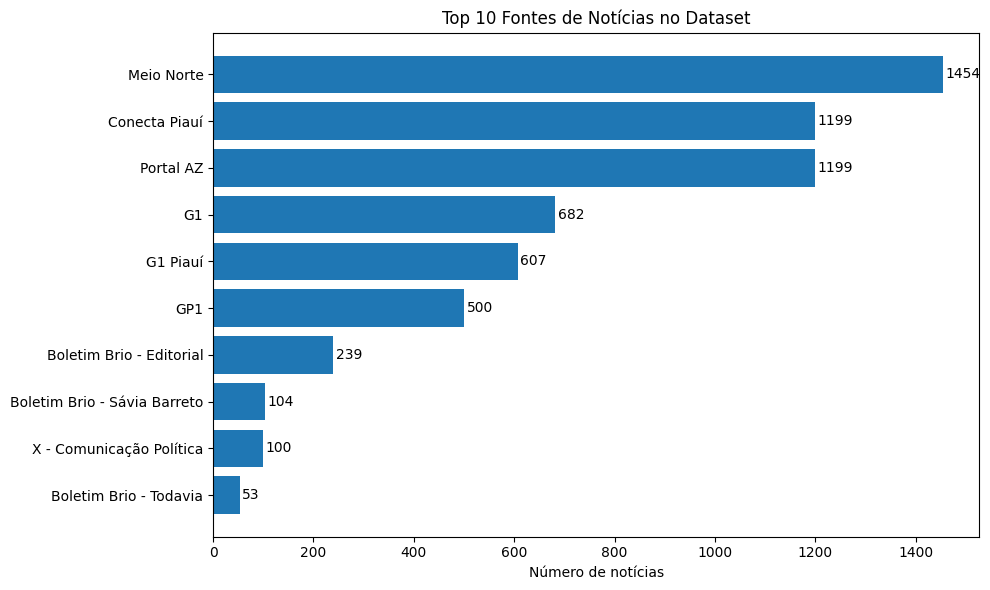

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# carregar dataset
articles_file = Path(clusters_path) / "articles_merged_cleaned_clustered_organized.csv"
df = pd.read_csv(articles_file)

# contar fontes
source_counts = df["source"].value_counts()

# pegar top 10
top_sources = source_counts.head(10)

# ordenar para gráfico horizontal ficar bonito
top_sources = top_sources.sort_values()

# plot
plt.figure(figsize=(10,6))

bars = plt.barh(top_sources.index, top_sources.values)

# adicionar valores nas barras
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center')

plt.xlabel("Número de notícias")
plt.title("Top 10 Fontes de Notícias no Dataset")

plt.tight_layout()
plt.show()

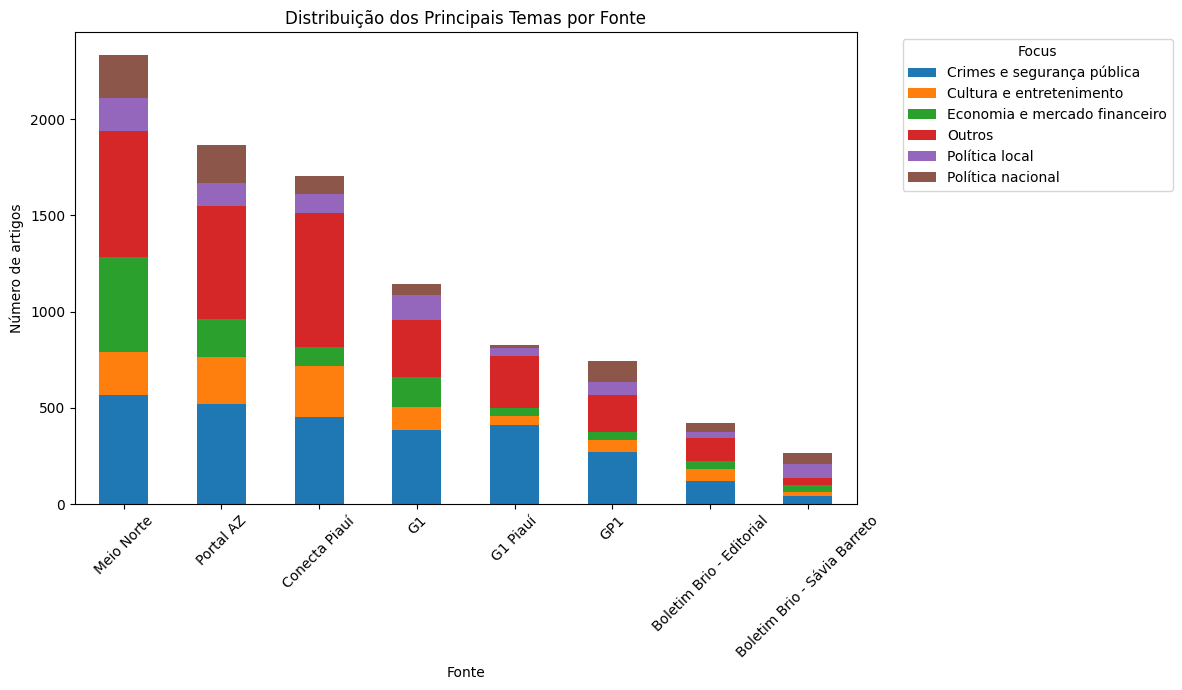

In [57]:
articles_file = Path(clusters_path) / "articles_merged_cleaned_clustered_organized.csv"

articles_df = pd.read_csv(articles_file)
clusters_df = pd.read_csv(news_file)

# juntar datasets
merged = articles_df.merge(
    clusters_df[["Cluster ID", "Focus", "Size"]],
    on="Cluster ID",
    how="left"
)

# separar múltiplos focos
# separar múltiplos focos
focus_expanded = (
    merged[["source", "Focus", "canonical_url"]]
    .dropna()
    .assign(Focus=lambda x: x["Focus"].str.split("|"))
    .explode("Focus")
)

focus_expanded["Focus"] = focus_expanded["Focus"].str.strip()

# pegar 5 focos principais
top_focus = focus_expanded["Focus"].value_counts().head(5).index

# agrupar restantes
focus_expanded["Focus_grouped"] = focus_expanded["Focus"].apply(
    lambda x: x if x in top_focus else "Outros"
)

# contar artigos únicos
source_focus_counts = (
    focus_expanded
    .groupby(["source", "Focus_grouped"])["canonical_url"]
    .nunique()
    .reset_index(name="count")
)

# pegar top fontes
top_sources = (
    focus_expanded["source"]
    .value_counts()
    .head(8)
    .index
)

filtered = source_focus_counts[
    source_focus_counts["source"].isin(top_sources)
]

# pivot para gráfico
pivot = filtered.pivot(
    index="source",
    columns="Focus_grouped",
    values="count"
).fillna(0)

# ordenar por volume total
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

# plot
pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7)
)

plt.xlabel("Fonte")
plt.ylabel("Número de artigos")
plt.title("Distribuição dos Principais Temas por Fonte")

plt.xticks(rotation=45)

plt.legend(
    title="Focus",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

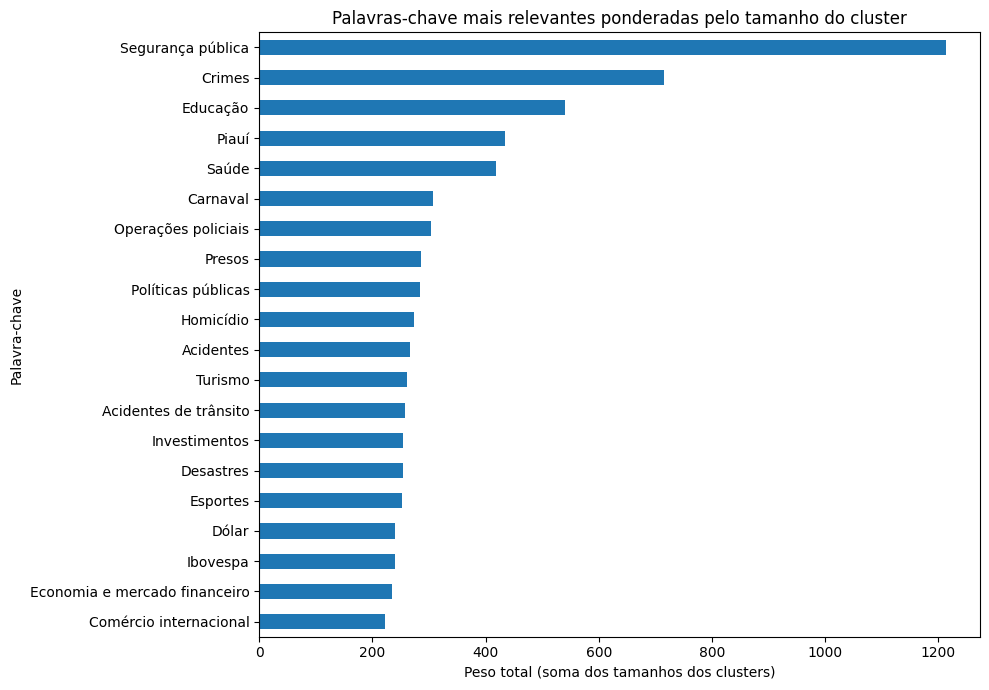

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

keywords_expanded = (
    clusters_df[["Keywords", "Size"]]
    .dropna()
    .assign(Keywords=lambda x: x["Keywords"].str.split(";"))
    .explode("Keywords")
)

keywords_expanded["Keywords"] = keywords_expanded["Keywords"].str.strip()

keyword_weight = (
    keywords_expanded
    .groupby("Keywords")["Size"]
    .sum()
    .sort_values(ascending=False)
)

top_keywords = keyword_weight.head(20)

plt.figure(figsize=(10,7))

top_keywords.sort_values().plot(kind="barh")

plt.xlabel("Peso total (soma dos tamanhos dos clusters)")
plt.ylabel("Palavra-chave")
plt.title("Palavras-chave mais relevantes ponderadas pelo tamanho do cluster")

plt.tight_layout()
plt.show()

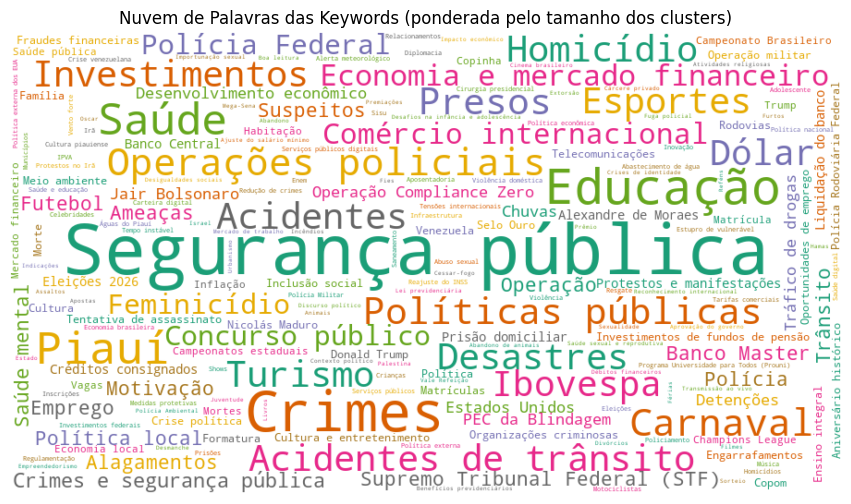

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# separar keywords
keywords_expanded = (
    clusters_df[["Keywords", "Size"]]
    .dropna()
    .assign(Keywords=lambda x: x["Keywords"].str.split(";"))
    .explode("Keywords")
)

keywords_expanded["Keywords"] = keywords_expanded["Keywords"].str.strip()

# calcular peso ponderado
keyword_weight = (
    keywords_expanded
    .groupby("Keywords")["Size"]
    .sum()
    .sort_values(ascending=False)
)

freq_dict = keyword_weight.to_dict()

colormap="Dark2"

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white",
    colormap="Dark2"
).generate_from_frequencies(freq_dict)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de Palavras das Keywords (ponderada pelo tamanho dos clusters)")
plt.show()

datetime64[ns, UTC]


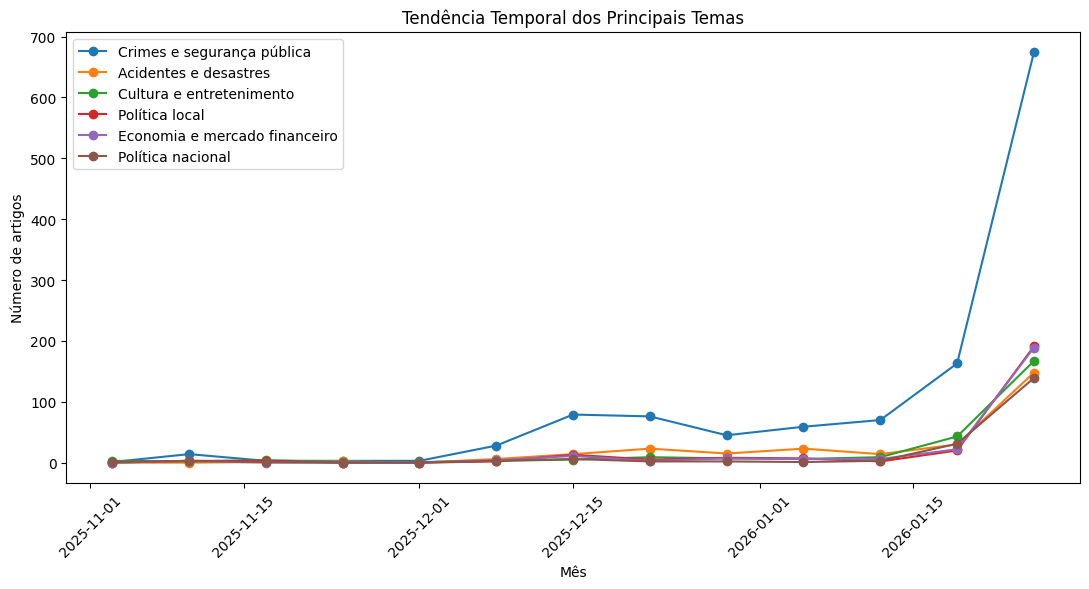

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# carregar datasets
articles_file = Path(clusters_path) / "articles_merged_cleaned_clustered_organized.csv"

news_df = pd.read_csv(articles_file)
clusters_df = pd.read_csv(news_file)

# converter datas
# converter datas (forma robusta)
news_df["publish_date"] = pd.to_datetime(
    news_df["publish_date"],
    errors="coerce",
    utc=True
)

# remover datas inválidas
news_df = news_df.dropna(subset=["publish_date"])

print(news_df["publish_date"].dtype)

# remover timezone
news_df["publish_date"] = news_df["publish_date"].dt.tz_localize(None)

# criar coluna mês
news_df["month"] = news_df["publish_date"].dt.to_period("M")

# juntar artigos com clusters
# filtrar datas
news_df = news_df[news_df["publish_date"] >= "2025-11-01"]

news_df["period"] = news_df["publish_date"]

merged = news_df.merge(
    clusters_df[["Cluster ID", "Focus"]],
    on="Cluster ID",
    how="left"
)

focus_expanded = (
    merged[["period", "Focus"]]
    .dropna()
    .assign(Focus=lambda x: x["Focus"].str.split("|"))
    .explode("Focus")
)

focus_expanded["Focus"] = focus_expanded["Focus"].str.strip()

trend = (
    focus_expanded
    .groupby([pd.Grouper(key="period", freq="7D"), "Focus"])
    .size()
    .reset_index(name="count")
)

trend_pivot = trend.pivot(index="period", columns="Focus", values="count").fillna(0)

# ordenar cronologicamente
trend_pivot = trend_pivot.sort_index()

# principais temas
top_topics = focus_expanded["Focus"].value_counts().head(6).index
trend_top = trend_pivot[top_topics]

# plot
plt.figure(figsize=(11,6))

for col in trend_top.columns:
    plt.plot(trend_top.index, trend_top[col], marker="o", label=col)

plt.xticks(rotation=45)
plt.ylabel("Número de artigos")
plt.xlabel("Mês")
plt.title("Tendência Temporal dos Principais Temas")
plt.legend()

plt.tight_layout()
plt.show()

C:\Users\enzom\AppData\Local\Temp\ipykernel_22524\2272559696.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dimensions_df = dimensions_df.applymap(clean_text)


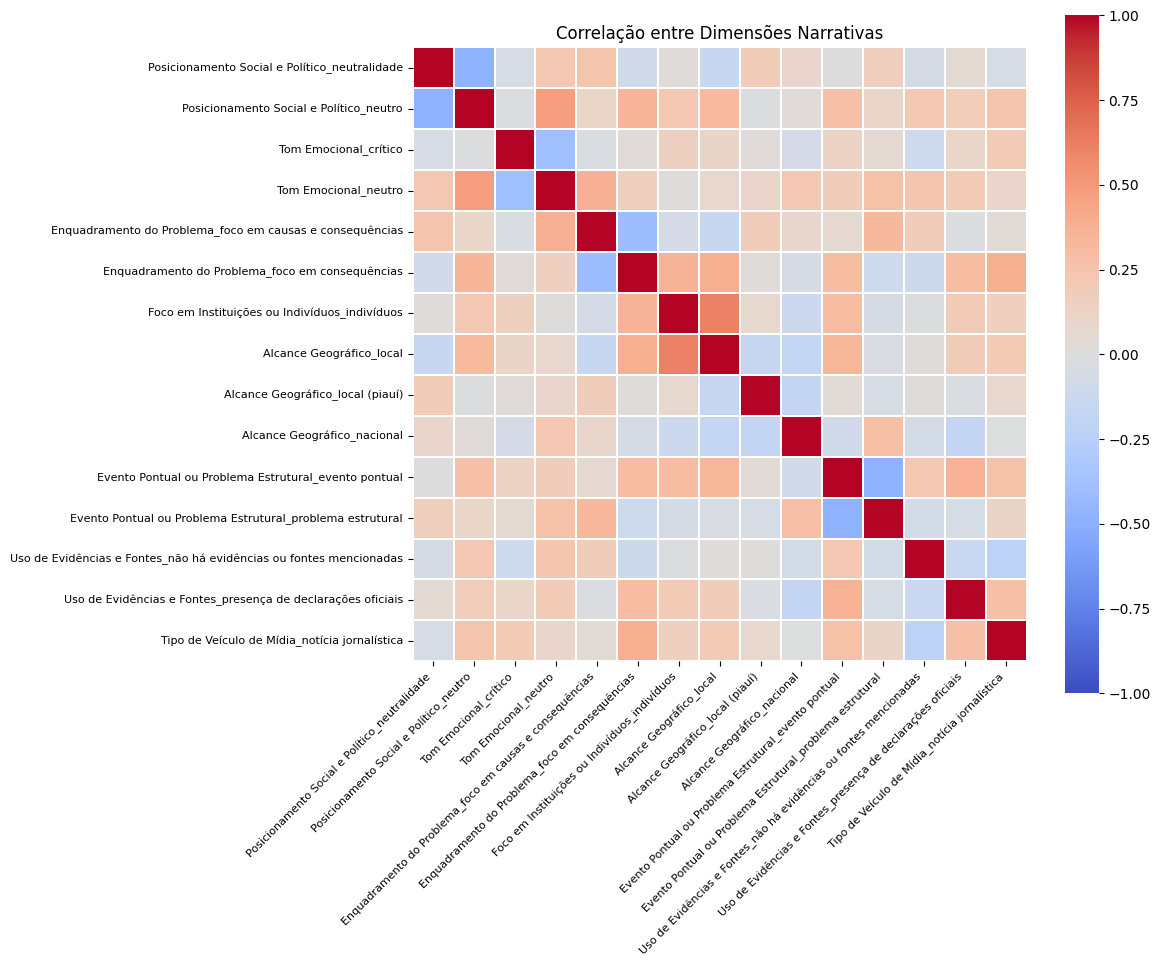

In [72]:
import pandas as pd
import re

df = pd.read_csv(news_file)

rows = []

for text in df["Dimensions"].dropna():

    dims = {}

    matches = re.findall(r"Dimensão\s*(\d+)\s*([^:]+):\s*(.*)", text)

    for num, name, value in matches:
        col = name.strip()
        dims[col] = value.strip()

    rows.append(dims)

dimensions_df = pd.DataFrame(rows)

def clean_text(x):
    if pd.isna(x):
        return x
    
    x = x.lower()
    x = re.sub(r"\.", "", x)
    x = x.strip()
    
    return x

dimensions_df = dimensions_df.applymap(clean_text)

dimensions_binary = pd.get_dummies(dimensions_df)

min_freq = 10

freq = dimensions_binary.sum()

keep_cols = freq[freq >= min_freq].index

dimensions_binary_filtered = dimensions_binary[keep_cols]

phi_matrix = dimensions_binary_filtered.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    phi_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.2
)

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)

plt.title("Correlação entre Dimensões Narrativas")

plt.tight_layout()
plt.show()